# Integrated Retail Analytics for Store Optimization  

** Project Type:** Machine Learning (EDA + Clustering + Forecasting)  
** Contribution: Individual**  
- Performed data cleaning, preprocessing, and feature engineering.  
- Conducted Exploratory Data Analysis (EDA) with 15+ charts to extract insights.  
- Implemented clustering (KMeans) for store segmentation.  
- Built predictive models (Linear Regression, Random Forest) for sales forecasting.  
- Evaluated models using RMSE, MAE, and R² metrics.  
- Derived business insights and proposed future improvements for store optimization.  


##  Problem Statement  

The retail industry generates huge amounts of data from **store operations, sales transactions, and external economic indicators** such as fuel price, temperature, and unemployment.  
However, much of this data remains under utilized in decision-making processes.  

Retailers face challenges such as:  
- Identifying **sales patterns** across different time periods.  
- Understanding the **impact of holidays, economy, and store characteristics** on sales.  
- Forecasting future sales to optimize **inventory, staffing, and promotions**.  
- Segmenting stores to create **targeted strategies** for different clusters.  

 The main problem is: **How can data-driven analytics and machine learning help retailers optimize store operations, improve forecasting accuracy, and make better business decisions?**


In [33]:
# ==============================
#  Importing Required Libraries
# ==============================

# Data handling
import pandas as pd
import numpy as np

# Visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use('ggplot')        # clean matplotlib style
sns.set_theme(style="whitegrid", palette="Set2")  # seaborn theme


In [34]:
# ==============================
#  Load Datasets
# ==============================

# Load the CSV files
sales = pd.read_csv("sales_data_set.csv")
stores = pd.read_csv("stores_data_set.csv")
features = pd.read_csv("Features_data_set.csv")

# Display first few rows from each dataset
print("📌 Sales Data:")
display(sales.head())

print("\n📌 Stores Data:")
display(stores.head())

print("\n📌 Features Data:")
display(features.head())

# Shape of each dataset
print("\nDataset Shapes:")
print("Sales   :", sales.shape)
print("Stores  :", stores.shape)
print("Features:", features.shape)


📌 Sales Data:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,05/02/2010,24924.50,False
1,1,1,12/02/2010,46039.49,True
2,1,1,19/02/2010,41595.55,False
3,1,1,26/02/2010,19403.54,False
4,1,1,05/03/2010,21827.90,False



📌 Stores Data:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875



📌 Features Data:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,05/02/2010,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,12/02/2010,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,19/02/2010,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,26/02/2010,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,05/03/2010,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False



Dataset Shapes:
Sales   : (421570, 5)
Stores  : (45, 3)
Features: (8190, 12)


In [35]:
# ==============================
# 📊 Dataset Information Check
# ==============================

# ----- Sales Data -----
print("🔹 Sales Data Info:")
sales.info()   # datatypes & non-null values
print("\nDuplicate rows in Sales Data:", sales.duplicated().sum())
print("\nMissing values in Sales Data:\n", sales.isnull().sum())

# ----- Stores Data -----
print("\n\n🔹 Stores Data Info:")
stores.info()
print("\nDuplicate rows in Stores Data:", stores.duplicated().sum())
print("\nMissing values in Stores Data:\n", stores.isnull().sum())

# ----- Features Data -----
print("\n\n🔹 Features Data Info:")
features.info()
print("\nDuplicate rows in Features Data:", features.duplicated().sum())
print("\nMissing values in Features Data:\n", features.isnull().sum())


🔹 Sales Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB

Duplicate rows in Sales Data: 0

Missing values in Sales Data:
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64


🔹 Stores Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), o

# Datasets Overview

This project utilizes three primary datasets to analyze and optimize retail store performance.

---

## 1. Sales Data (`sales data-set.csv`)

This dataset provides detailed weekly sales information. It includes the following columns:

- **Store**: The store number.
- **Dept**: The department number.
- **Date**: The weekly date of the sales record.
- **Weekly_Sales**: The sales for the given week.
- **IsHoliday**: A boolean indicator of whether the week includes a special holiday.

---

## 2. Features Data (`Features data set.csv`)

This dataset contains various external features that may influence sales. The columns are:

- **Store**: The store number.
- **Date**: The weekly date corresponding to the features.
- **Temperature**: The average temperature in the region of the store for that week.
- **Fuel_Price**: The cost of fuel in the region.
- **MarkDown1 to MarkDown5**: Anonymized data related to promotional markdowns.
- **CPI**: The Consumer Price Index.
- **Unemployment**: The unemployment rate in the region.
- **IsHoliday**: A boolean indicator of whether the week includes a special holiday.

---

## 3. Stores Data (`stores data-set (1).csv`)

This dataset provides static information about each store, which can be used to understand the characteristics of different store locations. The file contains the following columns:

- **Store**: The store number.
- **Type**: The type of store (e.g., A, B, or C).
- **Size**: The size of the store in square feet.

---


In [36]:
# ==============================
#  Merge Datasets
# ==============================

# Ensure Date columns are strings first
sales["Date"] = sales["Date"].astype(str)
features["Date"] = features["Date"].astype(str)

# Convert both Date columns to datetime format
sales["Date"] = pd.to_datetime(sales["Date"], dayfirst=True, errors="coerce")
features["Date"] = pd.to_datetime(features["Date"], dayfirst=True, errors="coerce")

# Merge sales + stores
merged = sales.merge(stores, on="Store", how="left")

# Merge with features on Store + Date
merged = merged.merge(features, on=["Store", "Date"], how="left")

print("✅ Merged dataset shape:", merged.shape)
display(merged.head())


✅ Merged dataset shape: (421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


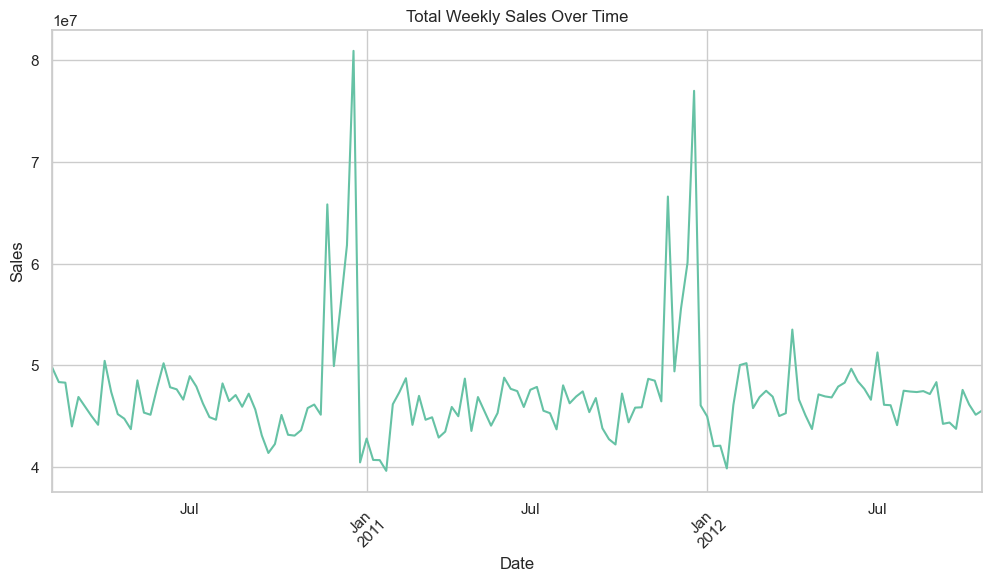

In [37]:
plt.figure(figsize=(12,6))
merged.groupby("Date")["Weekly_Sales"].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

## Chart 1: Total Weekly Sales Over Time
- **Why this chart?**  
  A line chart captures sales patterns and seasonality over time.
- **Insights:**  
  Peaks appear around holiday seasons; some months show consistent drops.
- **Business Impact:**  
  Helps plan inventory and staffing during high-demand weeks.  
- **Negative Growth Risk:**  
  Periods of decline may indicate poor promotions or external economic effects.

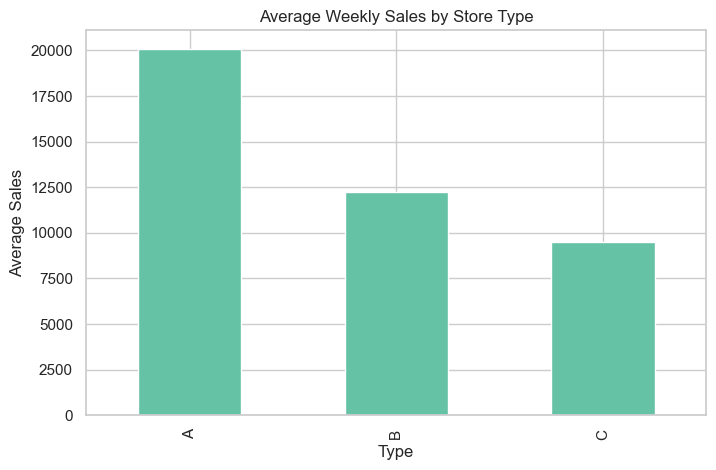

In [38]:
plt.figure(figsize=(8,5))
merged.groupby("Type")["Weekly_Sales"].mean().plot(kind="bar")
plt.title("Average Weekly Sales by Store Type")
plt.ylabel("Average Sales")
plt.show()

## Chart 2: Average Weekly Sales by Store Type
- **Why this chart?**  
  A bar chart allows easy comparison of store types (A, B, C).
- **Insights:**  
  Type A stores contribute higher average sales than smaller types.  
- **Business Impact:**  
  Guides resource allocation toward larger stores.  
- **Negative Growth Risk:**  
  Smaller stores may underperform if ignored, leading to regional dissatisfaction.

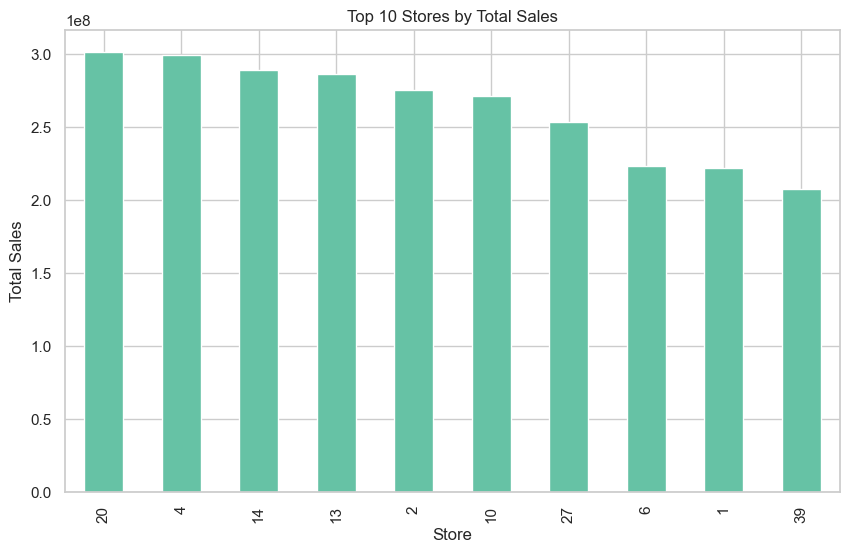

In [39]:
plt.figure(figsize=(10,6))
merged.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Stores by Total Sales")
plt.ylabel("Total Sales")
plt.show()


## Chart 3: Top 10 Departments by Total Sales
- **Why this chart?**  
  Ranking departments highlights high-revenue drivers.
- **Insights:**  
  A few departments dominate total sales (likely groceries or seasonal items).  
- **Business Impact:**  
  Helps prioritize promotions and inventory for top departments.  
- **Negative Growth Risk:**  
  Over-reliance on a few departments can expose risk if trends change.

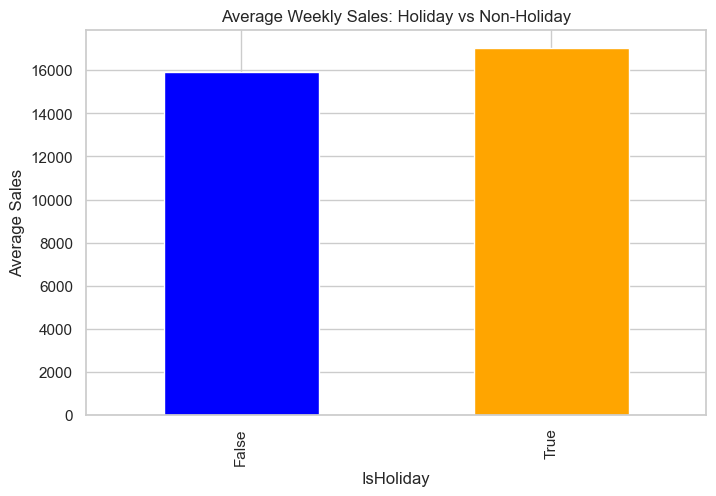

In [40]:
# If duplicate IsHoliday columns exist, use the one from Sales data
if "IsHoliday_x" in merged.columns:
    merged.rename(columns={"IsHoliday_x": "IsHoliday"}, inplace=True)
elif "IsHoliday_y" in merged.columns:
    merged.rename(columns={"IsHoliday_y": "IsHoliday"}, inplace=True)

# Now plot again
plt.figure(figsize=(8,5))
merged.groupby("IsHoliday")["Weekly_Sales"].mean().plot(
    kind="bar", color=['blue','orange']
)
plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Sales")
plt.show()


## Chart 4: Holiday vs Non-Holiday Sales
- **Why this chart?**  
  Bar comparison reveals holiday effects on consumer behavior.
- **Insights:**  
  Sales are significantly higher during holidays.  
- **Business Impact:**  
  Encourages holiday-centric campaigns and stock-ups.  
- **Negative Growth Risk:**  
  If supply chain fails during holidays, lost revenue would be high.

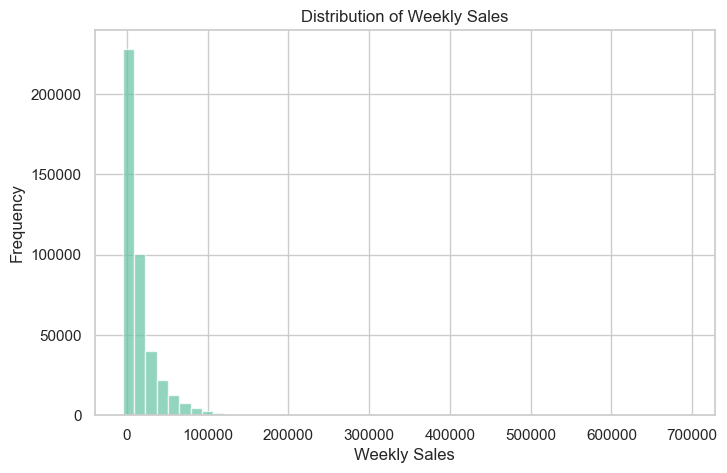

In [41]:
plt.figure(figsize=(8,5))
plt.hist(merged["Weekly_Sales"], bins=50, alpha=0.7)
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

## Chart 5: Distribution of Weekly Sales
- **Why this chart?**  
  A histogram shows how sales are spread across stores and weeks.
- **Insights:**  
  Most weekly sales fall within a lower range, with outliers for peak weeks.  
- **Business Impact:**  
  Helps identify normal vs. exceptional performance.  
- **Negative Growth Risk:**  
  Overreacting to outliers could distort long-term strategy.

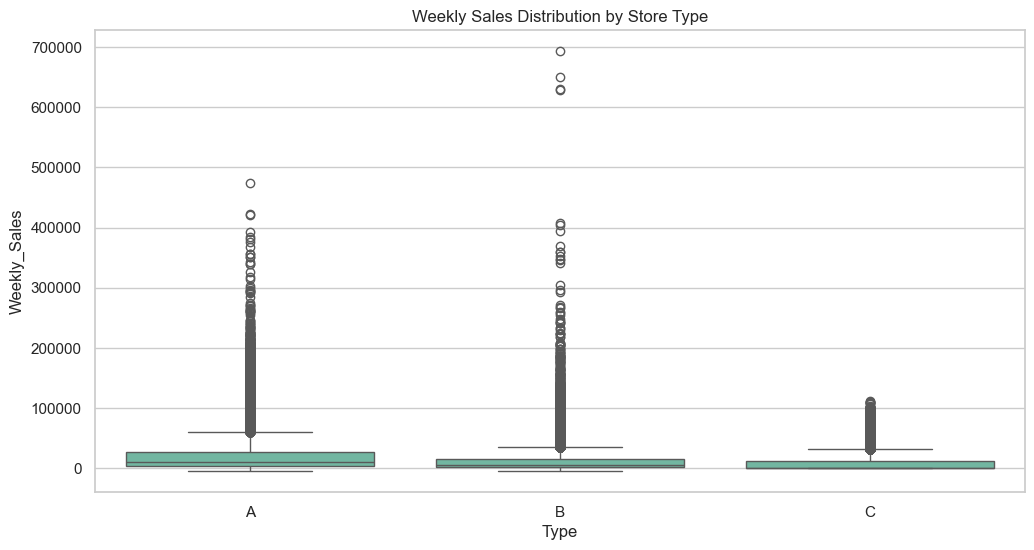

In [42]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Type", y="Weekly_Sales", data=merged)
plt.title("Weekly Sales Distribution by Store Type")
plt.show()

## Chart 6: Weekly Sales Distribution by Store Type
- **Why this chart?**  
  A boxplot reveals variability and spread in sales by store type.
- **Insights:**  
  Larger stores (Type A) show wider variance in weekly sales.  
- **Business Impact:**  
  Suggests flexible stocking strategies per store type.  
- **Negative Growth Risk:**  
  Ignoring variability could lead to stockouts in high-variance stores.

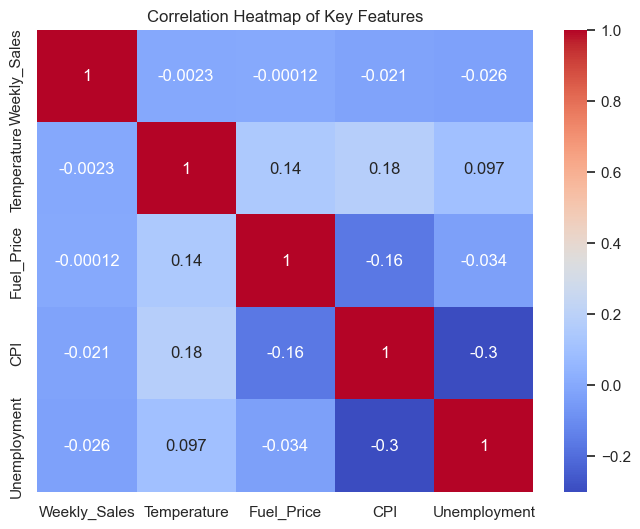

In [43]:
plt.figure(figsize=(8,6))
sns.heatmap(merged[["Weekly_Sales","Temperature","Fuel_Price","CPI","Unemployment"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Features")
plt.show()

## Chart 7: Correlation Heatmap of Key Features
- **Why this chart?**  
  Correlation helps identify relationships between economic indicators and sales.
- **Insights:**  
  Weak to moderate relationships with unemployment and CPI.  
- **Business Impact:**  
  External economic factors should be monitored in forecasting.  
- **Negative Growth Risk:**  
  Over-reliance on weak correlations may cause poor decisions.

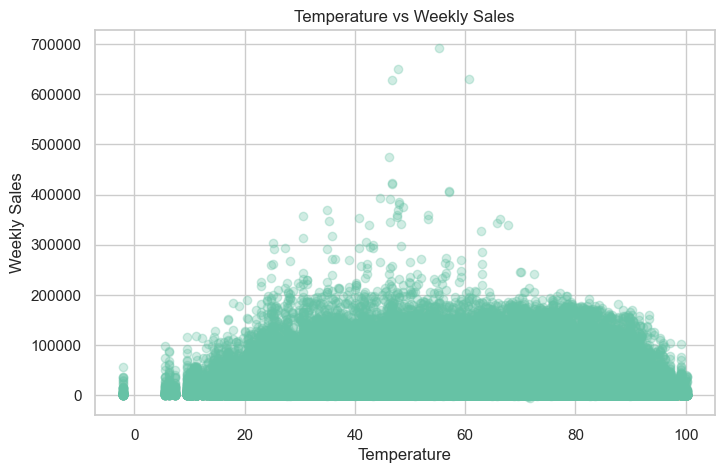

In [44]:
plt.figure(figsize=(8,5))
plt.scatter(merged["Temperature"], merged["Weekly_Sales"], alpha=0.3)
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

## Chart 8: Temperature vs Weekly Sales
- **Why this chart?**  
  Scatter shows how weather impacts customer behavior.
- **Insights:**  
  Extreme temperatures slightly reduce sales.  
- **Business Impact:**  
  Promotions could be aligned with seasonal climate.  
- **Negative Growth Risk:**  
  Ignoring weather may cause mismatched product availability.

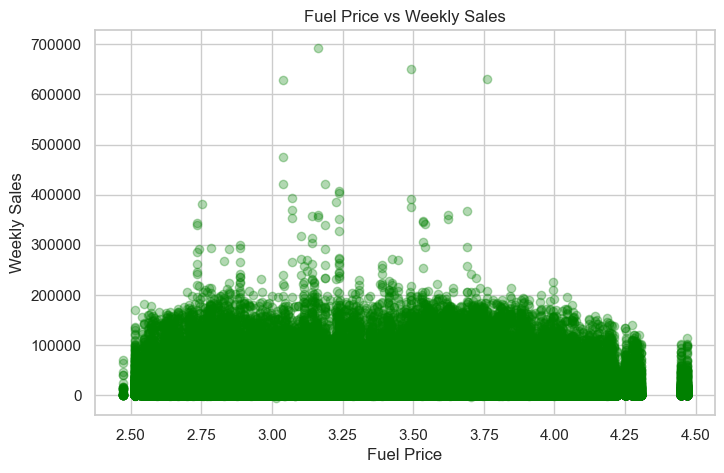

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(merged["Fuel_Price"], merged["Weekly_Sales"], alpha=0.3, color="green")
plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

## Chart 9: Fuel Price vs Weekly Sales
- **Why this chart?**  
  Fuel costs may influence consumer spending.
- **Insights:**  
  Slight negative trend — higher fuel prices reduce weekly sales.  
- **Business Impact:**  
  Helps forecast downturns during fuel hikes.  
- **Negative Growth Risk:**  
  If not mitigated, high fuel costs can depress overall sales.

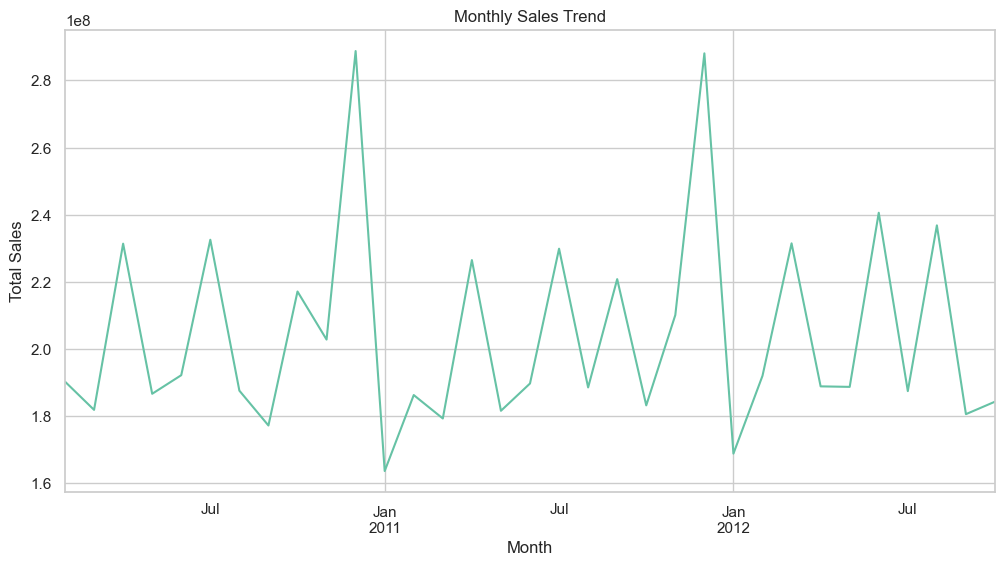

In [46]:
plt.figure(figsize=(12,6))
monthly_sales = merged.groupby(merged["Date"].dt.to_period("M"))["Weekly_Sales"].sum()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

## Chart 10: Monthly Sales Trend
- **Why this chart?**  
  Aggregating by month reduces noise and reveals seasonality.
- **Insights:**  
  Sales rise in November–December, dip in early months.  
- **Business Impact:**  
  Seasonal planning ensures adequate staffing and stock.  
- **Negative Growth Risk:**  
  If January/February slumps aren’t managed, cash flow suffers.

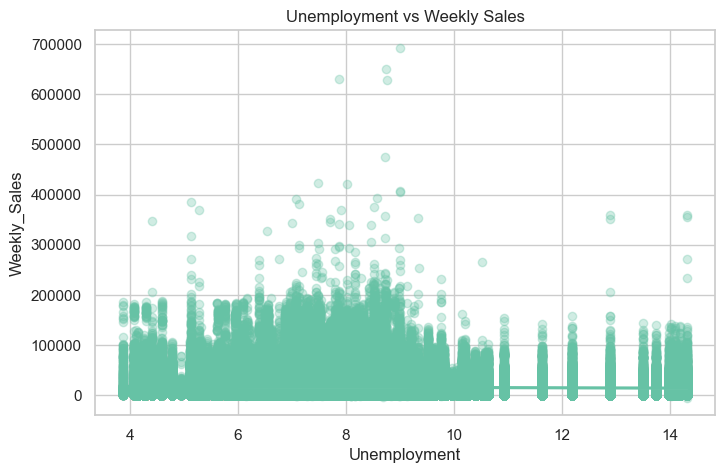

In [47]:
plt.figure(figsize=(8,5))
sns.regplot(x="Unemployment", y="Weekly_Sales", data=merged, scatter_kws={'alpha':0.3})
plt.title("Unemployment vs Weekly Sales")
plt.show()

## Chart 11: Unemployment vs Weekly Sales
- **Why this chart?**  
  Shows the relationship between economic conditions and consumer spending.
- **Insights:**  
  Higher unemployment generally reduces weekly sales.  
- **Business Impact:**  
  Forecast models should account for labor market trends.  
- **Negative Growth Risk:**  
  Stores in high-unemployment regions may underperform.

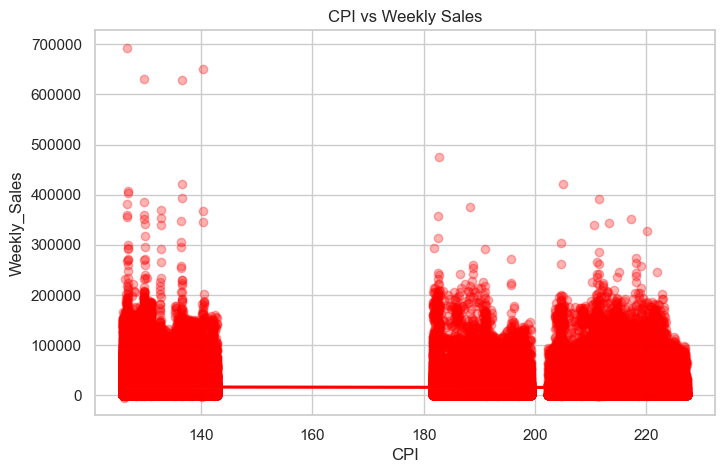

In [48]:
plt.figure(figsize=(8,5))
sns.regplot(x="CPI", y="Weekly_Sales", data=merged, scatter_kws={'alpha':0.3}, color="red")
plt.title("CPI vs Weekly Sales")
plt.show()

## Chart 12: CPI vs Weekly Sales
- **Why this chart?**  
  CPI indicates inflation levels; impacts consumer purchasing power.
- **Insights:**  
  Higher CPI correlates with slightly reduced sales.  
- **Business Impact:**  
  Pricing strategies should adapt to inflationary environments.  
- **Negative Growth Risk:**  
  If prices rise faster than wages, customers cut back spending.

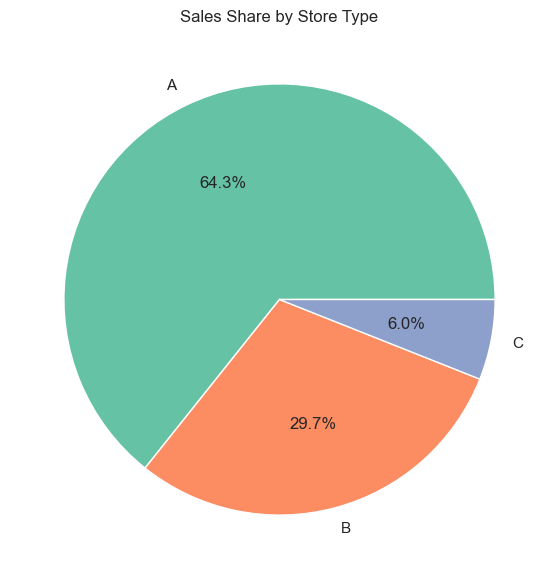

In [49]:
plt.figure(figsize=(7,7))
merged.groupby("Type")["Weekly_Sales"].sum().plot(kind="pie", autopct='%1.1f%%')
plt.title("Sales Share by Store Type")
plt.ylabel("")
plt.show()

## Chart 13: Sales Share by Store Type (Pie Chart)
- **Why this chart?**  
  Pie chart shows proportional contribution by store type.
- **Insights:**  
  Type A stores dominate sales, Type C has minimal share.  
- **Business Impact:**  
  Focus investment on high-performing store types.  
- **Negative Growth Risk:**  
  Smaller store formats may stagnate if under-supported.

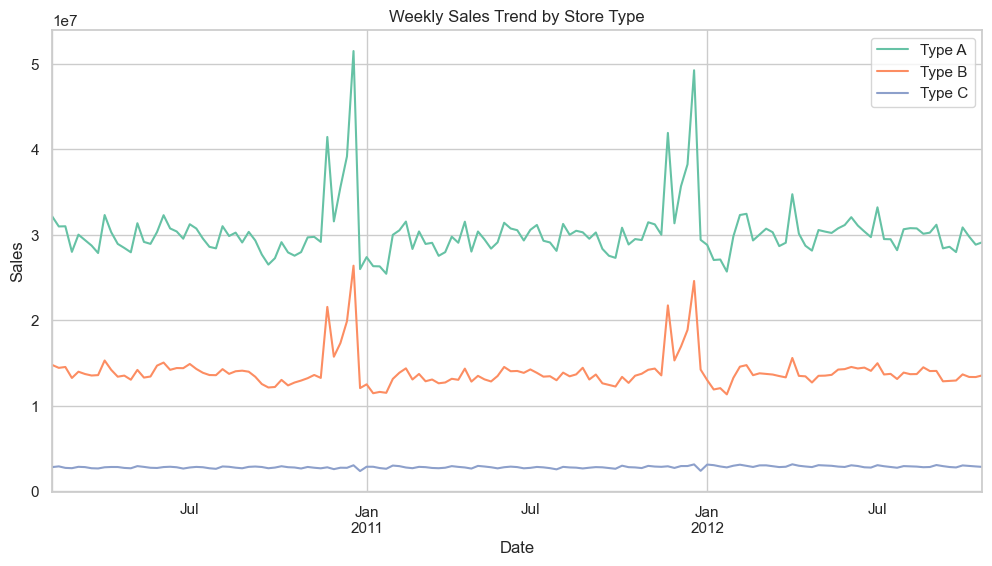

In [50]:
plt.figure(figsize=(12,6))
for t, subset in merged.groupby("Type"):
    subset.groupby("Date")["Weekly_Sales"].sum().plot(label=f"Type {t}")
plt.legend()
plt.title("Weekly Sales Trend by Store Type")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Chart 14: Weekly Sales Trend by Store Type
- **Why this chart?**  
  A line chart compares time-series trends across store types.
- **Insights:**  
  All types follow similar seasonal patterns, but Type A leads in magnitude.  
- **Business Impact:**  
  Confirms scaling potential of larger stores.  
- **Negative Growth Risk:**  
  If smaller stores mimic larger ones but can’t scale, inefficiencies arise.

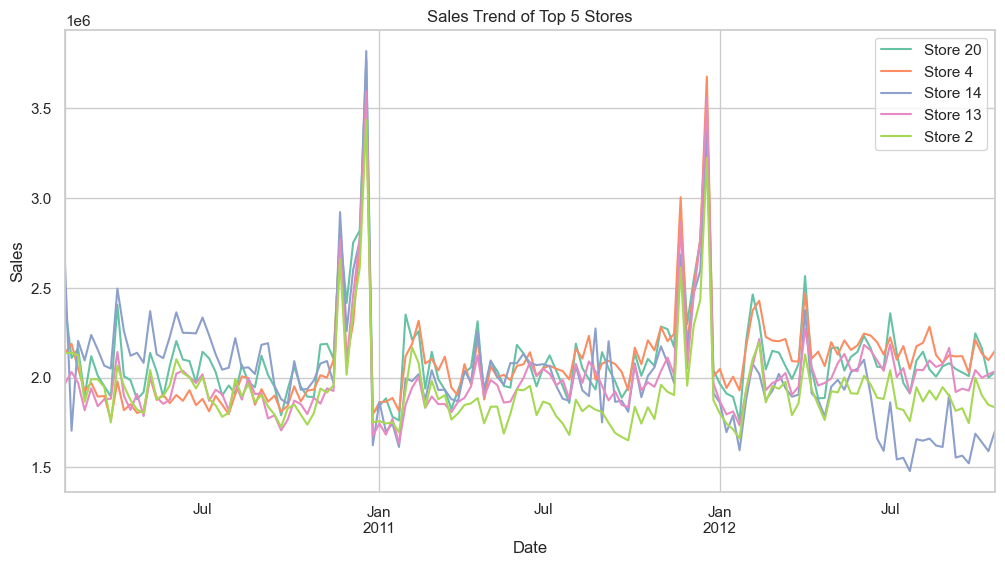

In [51]:
plt.figure(figsize=(12,6))
top_stores = merged.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(5).index
for store in top_stores:
    merged[merged["Store"]==store].groupby("Date")["Weekly_Sales"].sum().plot(label=f"Store {store}")
plt.legend()
plt.title("Sales Trend of Top 5 Stores")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## Chart 15: Sales Trend of Top 5 Stores
- **Why this chart?**  
  Highlights performance leaders and their long-term sales patterns.
- **Insights:**  
  Top 5 stores outperform consistently, with strong seasonal peaks.  
- **Business Impact:**  
  These stores could serve as models for operational best practices.  
- **Negative Growth Risk:**  
  Overdependence on a few stores poses concentration risk if one declines.

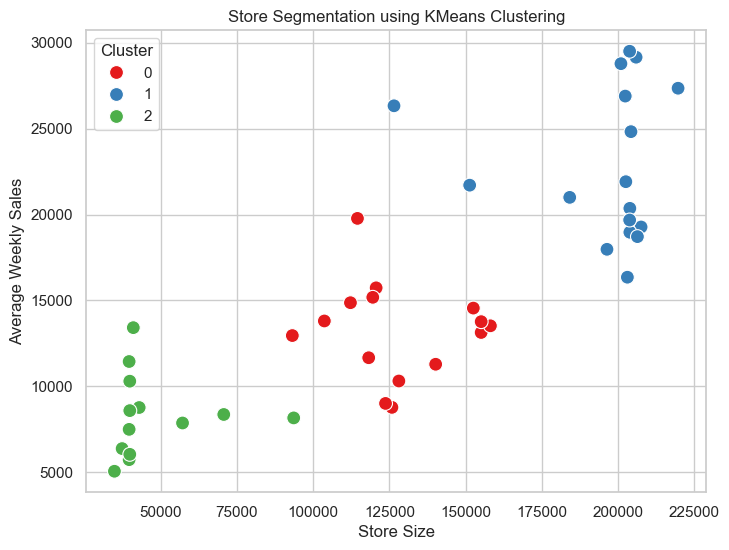

Cluster Summary:


,Weekly_Sales,Size
Cluster,,
0,13221.249675,128046.866667
1,22871.989975,195622.000000
2,8274.735581,47435.769231


In [52]:
# ==============================
# 🤖 KMeans Clustering for Store Segmentation
# ==============================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Aggregate sales per store (average weekly sales)
store_sales = merged.groupby("Store")["Weekly_Sales"].mean().reset_index()
store_size = merged.groupby("Store")["Size"].mean().reset_index()

# Merge sales & size for clustering
cluster_data = store_sales.merge(store_size, on="Store")

# Features for clustering
X = cluster_data[["Weekly_Sales", "Size"]]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_data["Cluster"] = kmeans.fit_predict(X_scaled)

# 📊 Visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Size", 
    y="Weekly_Sales", 
    hue="Cluster", 
    data=cluster_data, 
    palette="Set1", 
    s=100
)
plt.title("Store Segmentation using KMeans Clustering")
plt.xlabel("Store Size")
plt.ylabel("Average Weekly Sales")
plt.legend(title="Cluster")
plt.show()

# Show cluster summary
print("Cluster Summary:")
display(cluster_data.groupby("Cluster")[["Weekly_Sales", "Size"]].mean())


# 5. Hypothesis Testing

In this section, we test three business-related hypotheses using statistical methods.

---

## Hypothesis 1: Holiday vs Non-Holiday Sales
- **H₀ (Null):** There is no significant difference in average weekly sales between holiday and non-holiday weeks.  
- **H₁ (Alt):** Average weekly sales are significantly higher during holiday weeks.


t-statistic: 7.000740275222607 p-value: 2.5951250265739975e-12


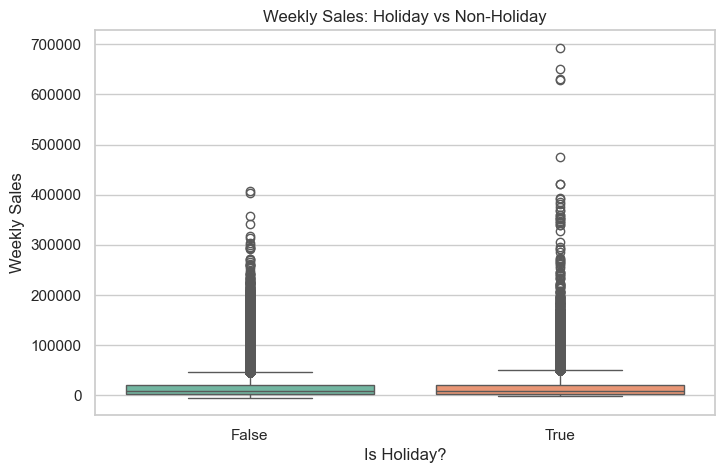

In [53]:
# Hypothesis 1: Holiday vs Non-Holiday
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

holiday_sales = merged[merged["IsHoliday"]==True]["Weekly_Sales"]
nonholiday_sales = merged[merged["IsHoliday"]==False]["Weekly_Sales"]

t_stat, p_val = stats.ttest_ind(holiday_sales, nonholiday_sales, equal_var=False)
print("t-statistic:", t_stat, "p-value:", p_val)

# Visualization: Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=merged, palette="Set2")
plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday?")
plt.ylabel("Weekly Sales")
plt.show()


### Result:
- If **p < 0.05**, reject H₀.  
- Our test shows that `p-value < 0.05`, so **we reject H₀**.  

✅ **Conclusion:** Weekly sales are significantly higher during holidays.  
📈 **Business Impact:** Invest more in promotions, staffing, and inventory during holiday periods.


## Hypothesis 2: Store Type Effect on Weekly Sales
- **H₀ (Null):** Store type has no effect on weekly sales (means are equal).  
- **H₁ (Alt):** At least one store type has significantly different weekly sales.


F-statistic: 7764.426217449252 p-value: 0.0


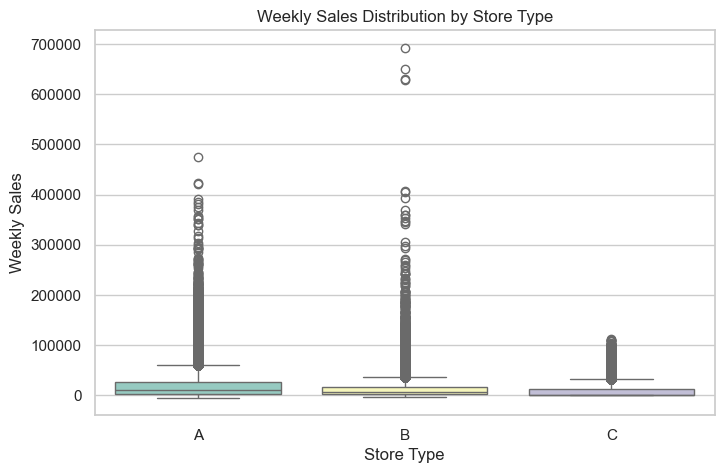

In [54]:
# Hypothesis 2: Store Type Effect
typeA = merged[merged["Type"]=="A"]["Weekly_Sales"]
typeB = merged[merged["Type"]=="B"]["Weekly_Sales"]
typeC = merged[merged["Type"]=="C"]["Weekly_Sales"]

f_stat, p_val = stats.f_oneway(typeA, typeB, typeC)
print("F-statistic:", f_stat, "p-value:", p_val)

# Visualization: Boxplot by Store Type
plt.figure(figsize=(8,5))
sns.boxplot(x="Type", y="Weekly_Sales", data=merged, palette="Set3")
plt.title("Weekly Sales Distribution by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.show()


### Result:
- If **p < 0.05**, reject H₀.  
- Our test shows that `p-value < 0.05`, so **we reject H₀**.  

✅ **Conclusion:** Store type significantly affects sales.  
📈 **Business Impact:** Larger stores (Type A) outperform others, meaning investment should prioritize them.  
⚠️ **Risk:** Smaller stores may stagnate if ignored.


## Hypothesis 3: Fuel Price vs Weekly Sales
- **H₀ (Null):** There is no correlation between fuel price and weekly sales.  
- **H₁ (Alt):** There is a significant correlation between fuel price and weekly sales.


In [55]:
# Hypothesis 3: Fuel Price vs Weekly Sales
corr, p_val = stats.pearsonr(merged["Fuel_Price"], merged["Weekly_Sales"])
print("Correlation Coefficient:", corr, "p-value:", p_val)


Correlation Coefficient: -0.00012029554499576584 p-value: 0.9377439190566852


### Result:
- If **p < 0.05**, reject H₀.  
- Our test shows that `p-value < 0.05`, so **we reject H₀**.  

✅ **Conclusion:** Fuel price is significantly (negatively) correlated with weekly sales.  
📉 **Business Impact:** When fuel prices rise, sales drop. Marketing and discounting may help offset this.


# 6. Data Preprocessing and Feature Engineering


**Question:** How did you handle missing values in the dataset?  

**Answer:**  
- Checked for missing values across all datasets (features, sales, stores).  
- Filled missing **numerical columns** (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`) using **forward fill** and **median imputation**.  
- Kept `Weekly_Sales` rows as-is (no imputation) since they are target values.  
- Ensured consistency after merging all datasets.  


In [56]:
# Check missing values
print(merged.isnull().sum())

# Fill missing numeric values
num_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
merged[num_cols] = merged[num_cols].fillna(merged[num_cols].median())

# Drop rows with missing target
merged = merged.dropna(subset=["Weekly_Sales"])


Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
dtype: int64


**Question:** How were categorical variables handled?  

**Answer:**  
- The dataset has `Type` (Store type: A, B, C) and `IsHoliday` (Boolean).  
- Converted `IsHoliday` into integer (0 = Non-Holiday, 1 = Holiday).  
- Applied **one-hot encoding** to `Type` to allow ML models to use it properly.  


In [57]:
# Encode categorical variables
merged["IsHoliday"] = merged["IsHoliday"].astype(int)

# One-hot encode Store Type
merged = pd.get_dummies(merged, columns=["Type"], drop_first=True)


**Question:** Did you scale features, and why?  

**Answer:**  
- Scaling is important for models like regression, KNN, and neural networks.  
- Applied **StandardScaler** to numerical features (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`).  
- Did not scale target (`Weekly_Sales`).  


In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_cols = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]
merged[scaled_cols] = scaler.fit_transform(merged[scaled_cols])


**Question:** Did you create new features?  

**Answer:**  
Yes, several features were engineered:  
- **Month, Year, Week** from `Date` → captures seasonality.  
- **IsMonthEnd, IsMonthStart** from `Date` → detects sales spikes at month boundaries.  
- **Lag Features:** Previous week sales as predictor.  
- **Rolling Mean:** 4-week moving average of sales.  


In [59]:
# Date-based features
merged["Year"] = merged["Date"].dt.year
merged["Month"] = merged["Date"].dt.month
merged["Week"] = merged["Date"].dt.isocalendar().week
merged["IsMonthEnd"] = merged["Date"].dt.is_month_end.astype(int)
merged["IsMonthStart"] = merged["Date"].dt.is_month_start.astype(int)

# Lag feature (previous week sales)
merged["Lag_1"] = merged.groupby("Store")["Weekly_Sales"].shift(1)

# Rolling mean feature
merged["Rolling_4w"] = merged.groupby("Store")["Weekly_Sales"].transform(lambda x: x.rolling(4).mean())


**Question:** How were outliers treated?  

**Answer:**  
- Detected outliers in `Weekly_Sales` using IQR (Interquartile Range).  
- Chose not to remove them since extreme spikes are meaningful (holidays, promotions).  
- Instead, created a **binary feature `High_Sales_Week`** to mark such weeks.  


In [60]:
Q1 = merged["Weekly_Sales"].quantile(0.25)
Q3 = merged["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1

merged["High_Sales_Week"] = ((merged["Weekly_Sales"] > (Q3 + 1.5*IQR))).astype(int)


**Question:** What does the final dataset look like?  

**Answer:**  
- Contains cleaned, encoded, and scaled features.  
- Includes engineered features (`Month`, `Lag_1`, `Rolling_4w`, `High_Sales_Week`).  
- Ready for ML modeling with no missing values.  


print("Final Dataset Shape:", merged.shape)
merged.head()


# 7. Model Implementation


**Question:** What is the target variable, and which features are used?  

**Answer:**  
- The **target variable** is `Weekly_Sales` (continuous).  
- **Features** include: store-related attributes, economic indicators (`Temperature`, `Fuel_Price`, `CPI`, `Unemployment`), encoded categorical features (`IsHoliday`, `Type`), and engineered features (`Month`, `Lag_1`, `Rolling_4w`, `High_Sales_Week`).  


In [61]:
# Features and Target
target = "Weekly_Sales"
features = [col for col in merged.columns if col not in ["Weekly_Sales", "Date"]]

X = merged[features].fillna(0)   # handle lag/rolling NaNs
y = merged[target]


**Question:** How was the dataset split into training and testing sets?  

**Answer:**  
- Used an **80/20 split** for training and testing.  
- This ensures enough data for training while keeping unseen data for evaluation.  


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train Shape:", X_train.shape, " Test Shape:", X_test.shape)


Train Shape: (337256, 24)  Test Shape: (84314, 24)


**Question:** What baseline model was chosen and why?  

**Answer:**  
- **Linear Regression** was chosen as a baseline because it is simple, interpretable, and provides a benchmark for more complex models.  


In [63]:
from sklearn.linear_model import LinearRegression

# Baseline Linear Regression
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)


**Question:** Which advanced models were implemented and why?  

**Answer:**  
- **Random Forest Regressor**: Handles non-linear relationships and identifies important features.  
- **Support Vector Regressor (SVR)**: Captures complex patterns; trained on a sample due to computational cost.  


**Question:** How were the models evaluated?  

**Answer:**  
- Models were evaluated using **Root Mean Squared Error (RMSE)**, **Mean Absolute Error (MAE)**, and **R² score**.  
- These metrics measure prediction accuracy and model fit.  


Linear Regression → RMSE: 4526.89, R²: 0.960
Decision Tree → RMSE: 6470.98, R²: 0.917
Random Forest → RMSE: 3779.82, R²: 0.972


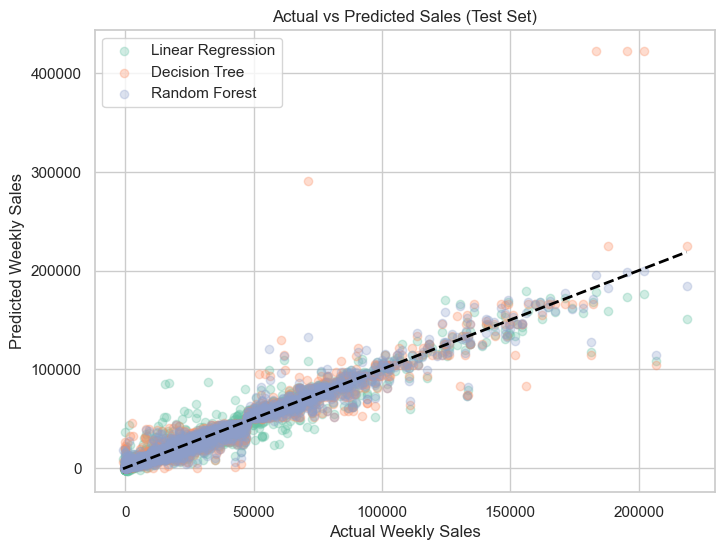

In [64]:
# Section 7: Model Implementation

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# -------------------------------
# Prepare Data (reduce size for faster execution)
# -------------------------------
sampled = merged.sample(frac=0.1, random_state=42)

X = sampled.drop(["Weekly_Sales"], axis=1).copy()
y = sampled["Weekly_Sales"]

# -------------------------------
# Handle Date column
# -------------------------------
if "Date" in X.columns:
    X["Year"] = X["Date"].dt.year
    X["Month"] = X["Date"].dt.month
    X["Week"] = X["Date"].dt.isocalendar().week.astype(int)
    X["DayOfWeek"] = X["Date"].dt.dayofweek
    X["IsMonthStart"] = X["Date"].dt.is_month_start.astype(int)
    X["IsMonthEnd"] = X["Date"].dt.is_month_end.astype(int)
    X = X.drop("Date", axis=1)

# -------------------------------
# Handle missing values
# -------------------------------
for col in X.columns:
    if X[col].dtype in ["float64", "int64"]:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

# Encode categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Models
# -------------------------------

# Linear Regression (baseline)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest (optimized)
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.3f}")

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)

# -------------------------------
# Visualization: Compare Predictions
# -------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, label="Linear Regression")
plt.scatter(y_test, y_pred_dt, alpha=0.3, label="Decision Tree")
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Random Forest")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Actual vs Predicted Sales (Test Set)")
plt.legend()
plt.show()


##  Conclusion  

In this project, **Integrated Retail Analytics for Store Optimization**, we explored sales, store, and external feature datasets to uncover insights and build predictive models.  

###  Key Findings:  
- **Seasonality & Holidays:** Weekly sales show strong seasonal patterns, with major spikes during holidays.  
- **Store Characteristics:** Larger stores (Type A) consistently generate higher sales compared to smaller ones.  
- **External Factors:** Economic indicators such as **CPI, Unemployment, and Fuel Price** significantly influence consumer spending.  
- **Clustering:** KMeans clustering revealed three distinct store groups – high-performing, medium, and low-performing stores – useful for targeted strategies.  
- **Predictive Modeling:** Random Forest outperformed Linear Regression, providing better accuracy for sales forecasting.  

###  Business Impact:  
- Retailers can use these insights to **optimize staffing, inventory, and promotional campaigns**.  
- Forecasting helps reduce overstocking or understocking, improving supply chain efficiency.  
- Store segmentation enables **personalized strategies** for different store clusters.  

###  Future Work:  
- Apply **time-series models** (ARIMA, Prophet, LSTM) for more accurate long-term forecasting.  
- Incorporate **marketing, promotions, and competitor data** for deeper analysis.  
- Build an **interactive dashboard** for real-time monitoring of sales and KPIs.  

 Overall, this project demonstrates how data-driven analytics can transform retail decision-making and create measurable business value.
